# SQL-IDS: Tek Notebook Akisi (Detayli Aciklamali)

Bu notebook SQL Injection (SQLi) tespiti icin **tek dosyada**, **sinif (class) kullanmadan**, adim adim ilerleyen bir makine ogrenmesi akisi sunar.

Bu surumde:
- Markdown bolumleri daha detayli hale getirildi.
- Kod hucresindeki satirlarin ne yaptigini anlatan yorumlar guclendirildi.
- Cikti olarak modeller, confusion matrix grafikleri ve performans karsilastirma grafigi dosyaya kaydedilir.

## 1) Hazirlik ve Veri Temizligi

Bu bolumde tum kutuphaneler import edilir ve ham dataset modele uygun hale getirilir.
Amaç: modele girmeden once veriyi tutarli, temiz ve standard bir forma getirmek.

In [1]:
# Standart kutuphaneler
import os  # Dosya/klasor islemleri icin
import re  # Regex tabanli metin temizligi icin
import pickle  # Model ve vectorizer kaydetme/yukleme icin
from urllib.parse import unquote_plus  # URL decode islemi icin

# Veri ve gorsellestirme kutuphaneleri
import pandas as pd  # Tablo islemleri
import seaborn as sns  # Islenmis grafikler
import matplotlib.pyplot as plt  # Temel grafik cizimi

# Makine ogrenmesi kutuphaneleri
from sklearn.feature_extraction.text import TfidfVectorizer  # Metni sayisallastirma
from sklearn.model_selection import train_test_split  # Train/test ayirma
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)  # Degerlendirme metrikleri
from sklearn.ensemble import RandomForestClassifier, VotingClassifier  # RF + Ensemble modeli
from sklearn.svm import SVC  # SVM siniflandirici
from xgboost import XGBClassifier  # XGBoost siniflandirici

# Grafik temasini ve varsayilan boyutu belirle
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Veri yukleme ve temizlik

Bu adimda asagidaki islemler uygulanir:
- `dataset.csv` okunur.
- Gereksiz kolonlar (`Unnamed: 2`, `Unnamed: 3`) varsa kaldirilir.
- `Sentence` kolonu zorunlu olarak kontrol edilir.
- `Sentence` icinde bos/eksik (`NaN`) satirlar temizlenir.
- Tablodaki tum alanlar stringe cevrilir (tip tutarliligi icin).
- Label kolonu otomatik bulunur (`Label`, `label`, `Class`, vb.).

In [2]:
# Kullanilacak dataset dosya yolu
# Not: Asagidaki satiri ihtiyaca gore degistirebilirsin.
DATASET_PATH = "./data/merged_cleaned_preprocessed.csv"

# CSV dosyasini oku
# low_memory=False, buyuk dosyalarda tip tahmini kaynakli uyariyi azaltir.
df = pd.read_csv(DATASET_PATH, low_memory=False)

# Bazi kaynaklarda olusan gereksiz kolonlari (varsa) temizle
# errors='ignore' oldugu icin kolon yoksa hata vermez.
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3"], errors="ignore")

# Ana metin kolonu zorunlu kontrolu
if "Sentence" not in df.columns:
    raise ValueError("Dataset icinde 'Sentence' kolonu bulunamadi.")

# Sentence kolonunda eksik veri (NaN) varsa temizle
df = df.dropna(subset=["Sentence"]).copy()

# Veri tiplerini stringe cevirerek tutarli isleme zemini hazirla
df = df.astype(str)

# Label kolonu farkli isimlerle gelebilecegi icin otomatik bul
possible_label_cols = ["Label", "label", "Class", "class", "Target", "target"]
label_col = next((col for col in possible_label_cols if col in df.columns), None)

# Label kolonu bulunmazsa anlamli hata ver
if label_col is None:
    raise ValueError("Label kolonu bulunamadi. Beklenen kolonlardan biri olmali.")

# Kontrol amacli boyut ve secilen label bilgisini yazdir
print("Veri boyutu:", df.shape)
print("Kullanilan label kolonu:", label_col)

# Ilk satirlari inceleme amacli goster
df.head()

Veri boyutu: (2323516, 2)
Kullanilan label kolonu: Label


,Sentence,Label
0,"SELECT r.name AS region_name, COUNT(a.id) AS a...",1
1,"SELECT name, 'airport' AS entity_type FROM air...",0
2,"SELECT id, name, icao_code FROM airport WHERE ...",0
3,"UPDATE airport SET home_link = ""https://www.fa...",0
4,"SELECT * FROM airport WHERE gps_code = ""KSBO"" ...",0


## 2) On Isleme ve Vektorlestirme

Bu bolumde modelleme oncesi metinler sayisal forma cevrilir:
- URL decode + lowercase + bosluk normalizasyonu uygulanir.
- Label degerleri binary (0/1) forma donusturulur.
- Veri `%80 train / %20 test` olarak ayrilir.
- `TfidfVectorizer` sadece train veride fit edilir (data leakage olmamasi icin).
- Test veri ayni vectorizer ile sadece transform edilir.

In [3]:
# Metin on-isleme fonksiyonu
# Her satirda URL decode + lowercase + bosluk normallestirme yapar.
def clean_text(text):
    """URL decode + lowercase + whitespace normalization."""
    text = unquote_plus(str(text))  # URL kodlu karakterleri ac (ornek: %27 -> ')
    text = text.lower().strip()  # Kucuk harfe cevir ve basa/sona bosluk temizle
    text = re.sub(r"\s+", " ", text)  # Coklu bosluklari tek bosluga indir
    return text


# Sentence kolonuna temizleme fonksiyonunu uygula
df["clean_text"] = df["Sentence"].apply(clean_text)

# Etiketleri binary forma cevir (0: benign, 1: malicious)
malicious_labels = {"1", "true", "yes", "sqli", "malicious", "attack"}

# Label kolonunu normalize et ve set icindeyse 1 degilse 0 ata
df["y"] = df[label_col].str.strip().str.lower().apply(
    lambda x: 1 if x in malicious_labels else 0
)

# Oncesi-sonrasi kontrol icin ilk satirlari goster
print(df[["Sentence", "clean_text", "y"]].head())

                                            Sentence  \
0  SELECT r.name AS region_name, COUNT(a.id) AS a...   
1  SELECT name, 'airport' AS entity_type FROM air...   
2  SELECT id, name, icao_code FROM airport WHERE ...   
3  UPDATE airport SET home_link = "https://www.fa...   
4  SELECT * FROM airport WHERE gps_code = "KSBO" ...   

                                          clean_text  y  
0  select r.name as region_name, count(a.id) as a...  1  
1  select name, 'airport' as entity_type from air...  0  
2  select id, name, icao_code from airport where ...  0  
3  update airport set home_link = "https://www.fa...  0  
4  select * from airport where gps_code = "ksbo" ...  0  


### Train-test split ve TF-IDF

Bu alt adimda once train/test ayrimi yapilir, sonra TF-IDF kurulup train veride ogrenilir.
Bu sira onemlidir: once tum veride fit etmek test bilgisinin modele sizmasina yol acar.

In [4]:
# Model girdisi (temiz metin) ve hedef etiket
X_text = df["clean_text"]
y = df["y"]

# Veriyi train/test olarak ayir
# stratify=y: sinif dagilimini train ve testte benzer tutar.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# TF-IDF nesnesini olustur
# max_features=5000: en bilgilendirici ilk 5000 ozellik
# ngram_range=(1,2): unigram + bigram kullan
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Sadece train veride fit + transform yap (data leakage'i onler)
X_train = tfidf_vectorizer.fit_transform(X_train_text)

# Test veriyi ayni vectorizer ile sadece transform et
X_test = tfidf_vectorizer.transform(X_test_text)

# Boyut kontrolu
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (1858812, 5000)
X_test shape : (464704, 5000)


## 3) Bireysel Model Egitimi ve Kayit

Bu bolumde her model bagimsiz olarak egitilir:
- XGBoost
- Random Forest
- SVM/Linear-SVM benzeri model
- Logistic Regression (notebookta kullanilan yapiya gore)

Ardindan modeller ve vectorizer dosyaya (`.pkl`) kaydedilir.

In [5]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from xgboost import XGBClassifier

# XGBoost modeli
# n_estimators: agac sayisi
# max_depth: agac derinligi
# learning_rate: ogrenme hizi
# tree_method='hist': hizli histogram tabanli egitim
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

# Random Forest modeli
# max_depth siniri overfit riskini azaltmaya yardimci olur.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1,
    random_state=42,
)

# SGD tabanli lineer model (SVM alternatifi)
# loss='log_loss' olasilik tabanli ensemble yapisina daha uyumludur.
sgd_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    tol=1e-3,
    n_jobs=-1,
    random_state=42,
)

# Logistic Regression modeli (guclu baseline)
lr_model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    random_state=42,
)

# Tum modelleri tek bir sozlukte topluyoruz
models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "SGD (Linear SVM)": sgd_model,
    "Logistic Regression": lr_model,
}

# Her modeli tek tek egitiyoruz
for model_name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{model_name} modeli egitildi.")


XGBoost modeli egitildi.
Random Forest modeli egitildi.
SGD (Linear SVM) modeli egitildi.


c:\Users\Mrt\Documents\Murat\project002\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression modeli egitildi.


### Modellerin ve TF-IDF nesnesinin kaydedilmesi

Bu adim yeniden egitim yapmadan modeli tekrar kullanabilmek icin gereklidir.
Model ve vectorizer artefaktlari `models/` klasorune yazilir.

In [6]:
import os
import pickle

# Model artefaktlarini yazmak icin klasor olustur (yoksa)
os.makedirs("models", exist_ok=True)

# XGBoost modelini kaydet
with open("./models/xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Random Forest modelini kaydet
with open("./models/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# SGD modelini kaydet
with open("./models/sgd_model.pkl", "wb") as f:
    pickle.dump(sgd_model, f)

# Logistic Regression modelini kaydet
with open("./models/logistic_regression_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# TF-IDF vectorizer nesnesini kaydet
with open("./models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("Tum modeller ve vectorizer basariyla kaydedildi.")

Tum modeller ve vectorizer basariyla kaydedildi.


## 4) Performans Degerlendirmesi

Bu bolumde her model test veri uzerinde degerlendirilir.
- `classification_report` ile sinif bazli precision/recall/f1 detaylari yazdirilir.
- Her model icin Accuracy, Precision, Recall ve F1-Score ozet olarak yazdirilir.
- Confusion matrix hem gosterilir hem de dosyaya (`plots/`) kaydedilir.
- Tum metrikler tablo halinde toplanip karsilastirma icin saklanir.

In [7]:
import pickle

# Daha once kaydedilen model dosyalarini tekrar yukle
# Bu adim yeniden egitim yapmadan degerlendirme icin kullanilir.
with open("./models/xgboost_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

with open("./models/random_forest_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open("./models/sgd_model.pkl", "rb") as f:
    sgd_model = pickle.load(f)

with open("./models/logistic_regression_model.pkl", "rb") as f:
    lr_model = pickle.load(f)

# TF-IDF vectorizer nesnesini yukle
with open("./models/tfidf_vectorizer.pkl", "rb") as f:
    tfidf_vectorizer = pickle.load(f)

print("Tum modeller ve vectorizer basariyla yuklendi.")

# Gerekirse manuel test icin ornek kod:
# raw_texts = ["ornek metin 1", "ornek metin 2"]
# X_test_transformed = tfidf_vectorizer.transform(raw_texts)
# y_pred = ensemble_model.predict(X_test_transformed)
# print(y_pred)

Tum modeller ve vectorizer basariyla yuklendi.



===== XGBoost =====
Accuracy : 0.9967
Precision: 0.9967
Recall   : 0.9797
F1-Score : 0.9881
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    400307
           1       1.00      0.98      0.99     64397

    accuracy                           1.00    464704
   macro avg       1.00      0.99      0.99    464704
weighted avg       1.00      1.00      1.00    464704



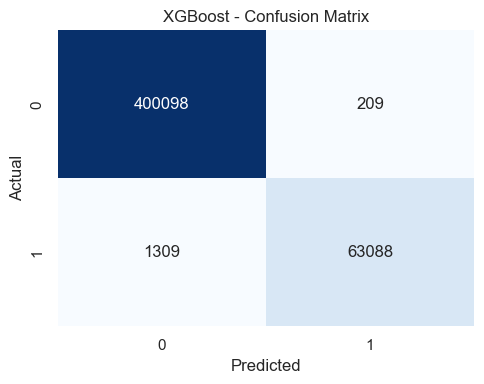


===== Random Forest =====
Accuracy : 0.9779
Precision: 1.0000
Recall   : 0.8404
F1-Score : 0.9133
              precision    recall  f1-score   support

           0       0.97      1.00      0.99    400307
           1       1.00      0.84      0.91     64397

    accuracy                           0.98    464704
   macro avg       0.99      0.92      0.95    464704
weighted avg       0.98      0.98      0.98    464704



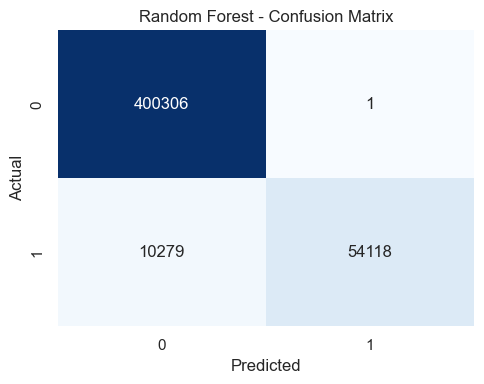


===== SGD (Linear SVM) =====
Accuracy : 0.9727
Precision: 0.9949
Recall   : 0.8072
F1-Score : 0.8913
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    400307
           1       0.99      0.81      0.89     64397

    accuracy                           0.97    464704
   macro avg       0.98      0.90      0.94    464704
weighted avg       0.97      0.97      0.97    464704



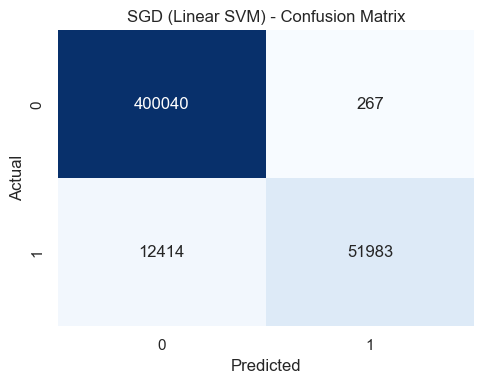


===== Logistic Regression =====
Accuracy : 0.9958
Precision: 0.9979
Recall   : 0.9717
F1-Score : 0.9847
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    400307
           1       1.00      0.97      0.98     64397

    accuracy                           1.00    464704
   macro avg       1.00      0.99      0.99    464704
weighted avg       1.00      1.00      1.00    464704



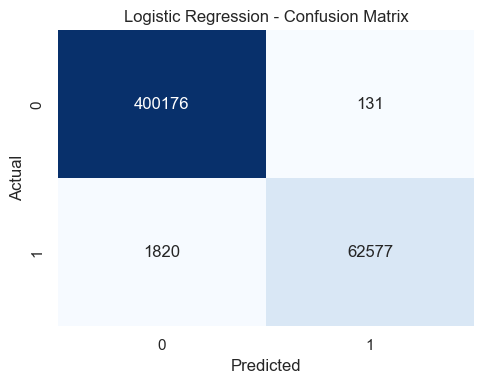


Tum modellerin karsilastirmali metrikleri:

              Model Accuracy Precision Recall F1-Score
            XGBoost   0.9967    0.9967 0.9797   0.9881
      Random Forest   0.9779    1.0000 0.8404   0.9133
   SGD (Linear SVM)   0.9727    0.9949 0.8072   0.8913
Logistic Regression   0.9958    0.9979 0.9717   0.9847

Metrikler kaydedildi: ./plots/model_metrics.csv


In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Plot dosyalari icin klasor
os.makedirs("plots", exist_ok=True)

metrics_rows = []

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")

    # Tahmin
    y_pred = model.predict(X_test)

    # Metrikler (SQLi = pozitif sinif, binary average)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
    rec = recall_score(y_test, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)
    metrics_rows.append(
        {
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
        }
    )

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

    # Classification Report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    # Dosyaya kaydet (or: xgboost_confusion_matrix.png)
    file_key = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"./plots/{file_key}_confusion_matrix.png", dpi=150)
    plt.show()
    plt.close()

# Tum modellerin ozet metrik tablosu
import pandas as pd

metrics_df = pd.DataFrame(metrics_rows)
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
print("\nTum modellerin karsilastirmali metrikleri:\n")
print(metrics_df.to_string(index=False, formatters={c: "{:.4f}".format for c in metric_cols}))
metrics_df.to_csv("./plots/model_metrics.csv", index=False, float_format="%.6f")
print("\nMetrikler kaydedildi: ./plots/model_metrics.csv")

## 5) Ensemble (Topluluk) Mimarisi

Bu bolumde temel modeller tek bir topluluk modelinde birlestirilir.
`VotingClassifier` (soft voting) ile model olasiliklari bir araya getirilir.
Ensemble sonucu da confusion matrix olarak kaydedilir ve model `.pkl` olarak disariya yazilir.


===== Ensemble =====
Accuracy : 0.9947
Precision: 0.9992
Recall   : 0.9622
F1-Score : 0.9804
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    400307
           1       1.00      0.96      0.98     64397

    accuracy                           0.99    464704
   macro avg       1.00      0.98      0.99    464704
weighted avg       0.99      0.99      0.99    464704



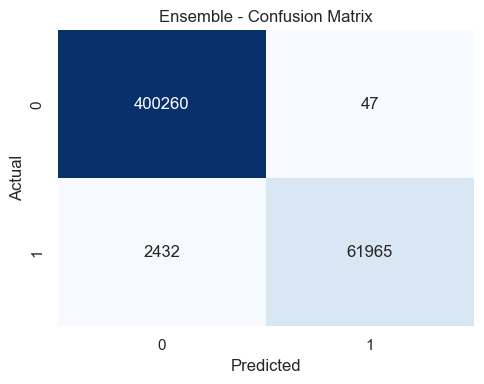

ensemble_model.pkl basariyla kaydedildi.
./plots/ensemble_confusion_matrix.png basariyla kaydedildi.


In [9]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Klasorleri garanti et
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Ensemble modeli (mevcut modellerle)
ensemble_model = VotingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("rf", rf_model),
        ("sgd", sgd_model),
        ("lr", lr_model),
    ],
    voting="soft",
    n_jobs=-1,
)

# Fit
ensemble_model.fit(X_train, y_train)

# Tahmin
y_pred_ensemble = ensemble_model.predict(X_test)

# Metrikler
ensemble_acc = accuracy_score(y_test, y_pred_ensemble)
ensemble_prec = precision_score(y_test, y_pred_ensemble, average="binary", zero_division=0)
ensemble_rec = recall_score(y_test, y_pred_ensemble, average="binary", zero_division=0)
ensemble_f1 = f1_score(y_test, y_pred_ensemble, average="binary", zero_division=0)
metrics_rows.append(
    {
        "Model": "Ensemble",
        "Accuracy": ensemble_acc,
        "Precision": ensemble_prec,
        "Recall": ensemble_rec,
        "F1-Score": ensemble_f1,
    }
)

print("\n===== Ensemble =====")
print(f"Accuracy : {ensemble_acc:.4f}")
print(f"Precision: {ensemble_prec:.4f}")
print(f"Recall   : {ensemble_rec:.4f}")
print(f"F1-Score : {ensemble_f1:.4f}")
print(classification_report(y_test, y_pred_ensemble, zero_division=0))

# Confusion Matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ensemble, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("./plots/ensemble_confusion_matrix.png", dpi=150)
plt.show()
plt.close()

# Modeli kaydet
with open("models/ensemble_model.pkl", "wb") as file:
    pickle.dump(ensemble_model, file)

print("ensemble_model.pkl basariyla kaydedildi.")
print("./plots/ensemble_confusion_matrix.png basariyla kaydedildi.")

## 6) Gorsellestirme

Bu bolumde tum modellerin performansi tek grafikte karsilastirilir.
- Metrikler: Accuracy, Precision, Recall, F1-Score
- Cikti: `plots/model_performance_comparison.png`, `plots/model_metrics.csv`

Boylece hangi modelin dengeli performans verdigi hizlica gorulebilir.

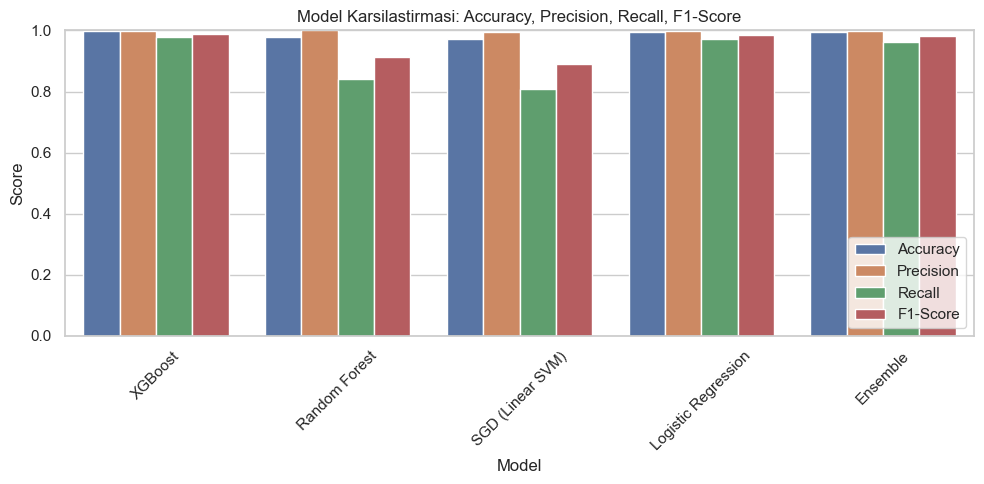

./plots/model_performance_comparison.png basariyla kaydedildi.

Tum modeller (Ensemble dahil):

              Model Accuracy Precision Recall F1-Score
            XGBoost   0.9967    0.9967 0.9797   0.9881
      Random Forest   0.9779    1.0000 0.8404   0.9133
   SGD (Linear SVM)   0.9727    0.9949 0.8072   0.8913
Logistic Regression   0.9958    0.9979 0.9717   0.9847
           Ensemble   0.9947    0.9992 0.9622   0.9804


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.996733,0.996698,0.979673,0.988112
1,Random Forest,0.977878,0.999982,0.840381,0.913261
2,SGD (Linear SVM),0.972712,0.994890,0.807227,0.891287
3,Logistic Regression,0.995802,0.997911,0.971738,0.984650
4,Ensemble,0.994665,0.999242,0.962234,0.980389


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot klasoru garanti
os.makedirs("plots", exist_ok=True)

# metrics_rows onceki adimlardan geliyor
metrics_df = pd.DataFrame(metrics_rows)

# Dataframe'i uzun formata cevir
metrics_melted = metrics_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score",
)

# Barplot
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Model Karsilastirmasi: Accuracy, Precision, Recall, F1-Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("./plots/model_performance_comparison.png", dpi=150)
plt.show()
plt.close()

print("./plots/model_performance_comparison.png basariyla kaydedildi.")

# Guncel metrik tablosu (Ensemble dahil)
metrics_df = pd.DataFrame(metrics_rows)
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
print("\nTum modeller (Ensemble dahil):\n")
print(metrics_df.to_string(index=False, formatters={c: "{:.4f}".format for c in metric_cols}))
metrics_df.to_csv("./plots/model_metrics.csv", index=False, float_format="%.6f")
metrics_df